In [1]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy import constants as cst
import sys, os, git
import warnings
warnings.filterwarnings("ignore")

In [2]:
current_path = os.getcwd()
git_repo = git.Repo(current_path, search_parent_directories=True)
git_path = git_repo.git.rev_parse("--show-toplevel")
path_figures = current_path[len(git_path):] + '/'
path_in_folder = current_path[len(git_path)+1:]

In [3]:
sys.path.append(git_path + "/.submodules/pyplot-perso")
from plttools import PltTools

In [4]:
cmap_cool = cm.cool
cmap_dark_blue_to_cyan = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(0.0)])
cmap_viridis = cm.viridis      # excellent general-purpose
cmap_cividis = cm.cividis      # best for accessibility (colorblind-safe)
cmap_turbo   = cm.turbo        # very high contrast, vivid range
cmap_plasma  = cm.plasma       # strong contrast, warm highlights
cmap_inferno = cm.inferno      # dark-to-bright, great on dark BG
cmap_magma   = cm.magma        # smoother dark-background readability

cmap_cool = cm.cool
cmap_cyan_to_green_blue = LinearSegmentedColormap.from_list(
    "cyan_to_green_blue", ["#0f55eb", "#00FFFF", "#00FA9A"])

  Pixels: width = 696.2 x height = 682.9
  Aspect ratio: 1.0194
  Pixels: width = 696.2 x height = 682.9
  Aspect ratio: 1.0194


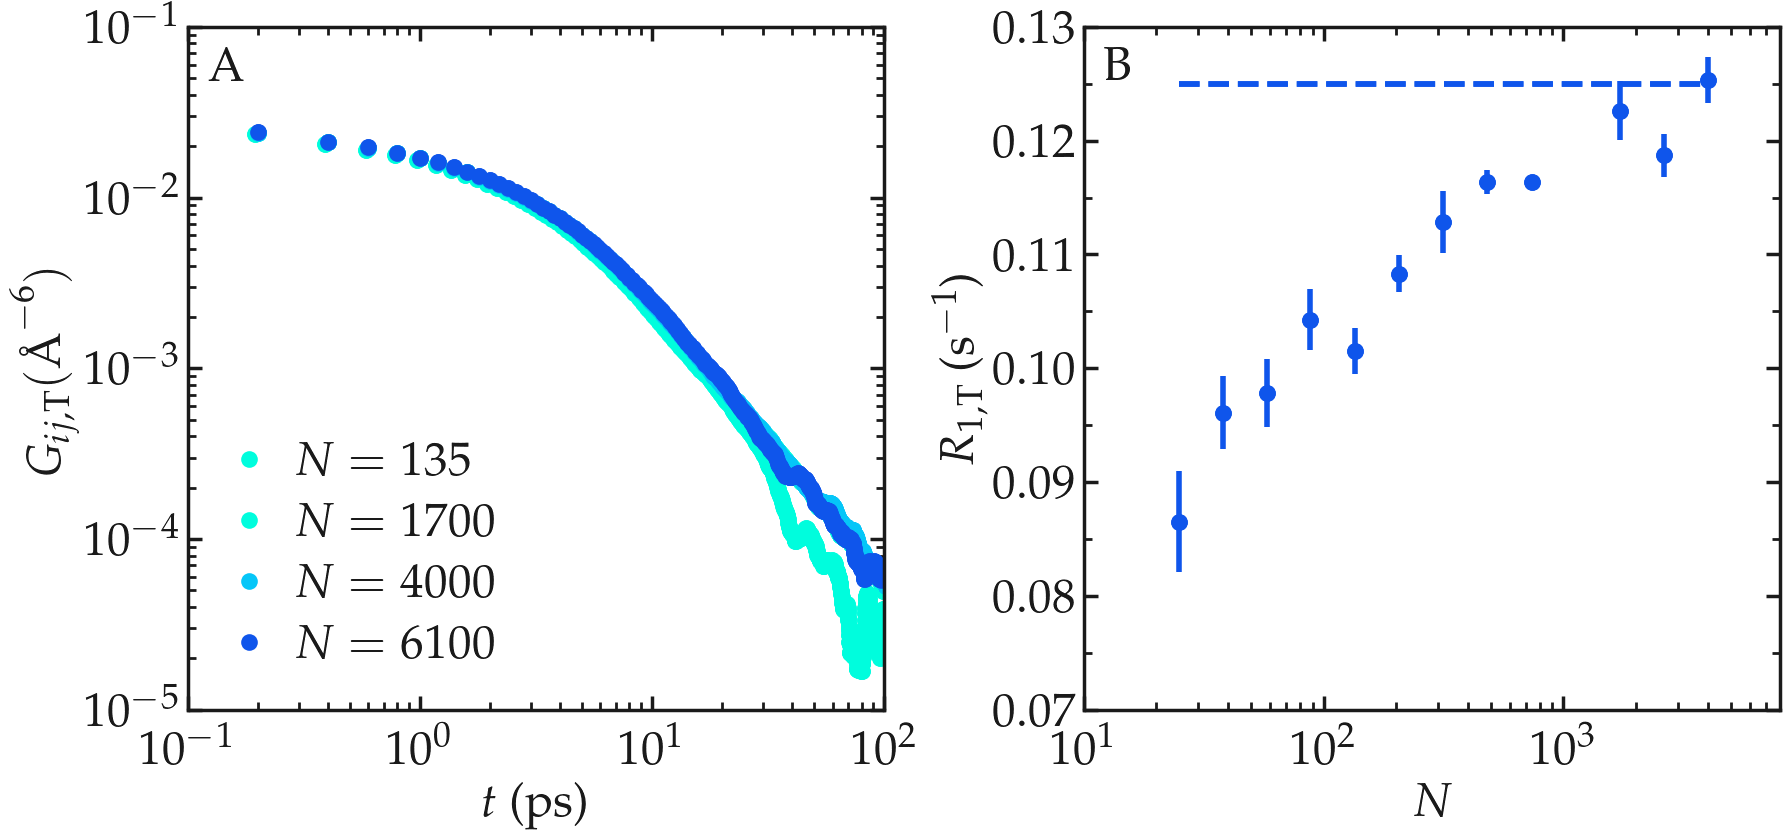

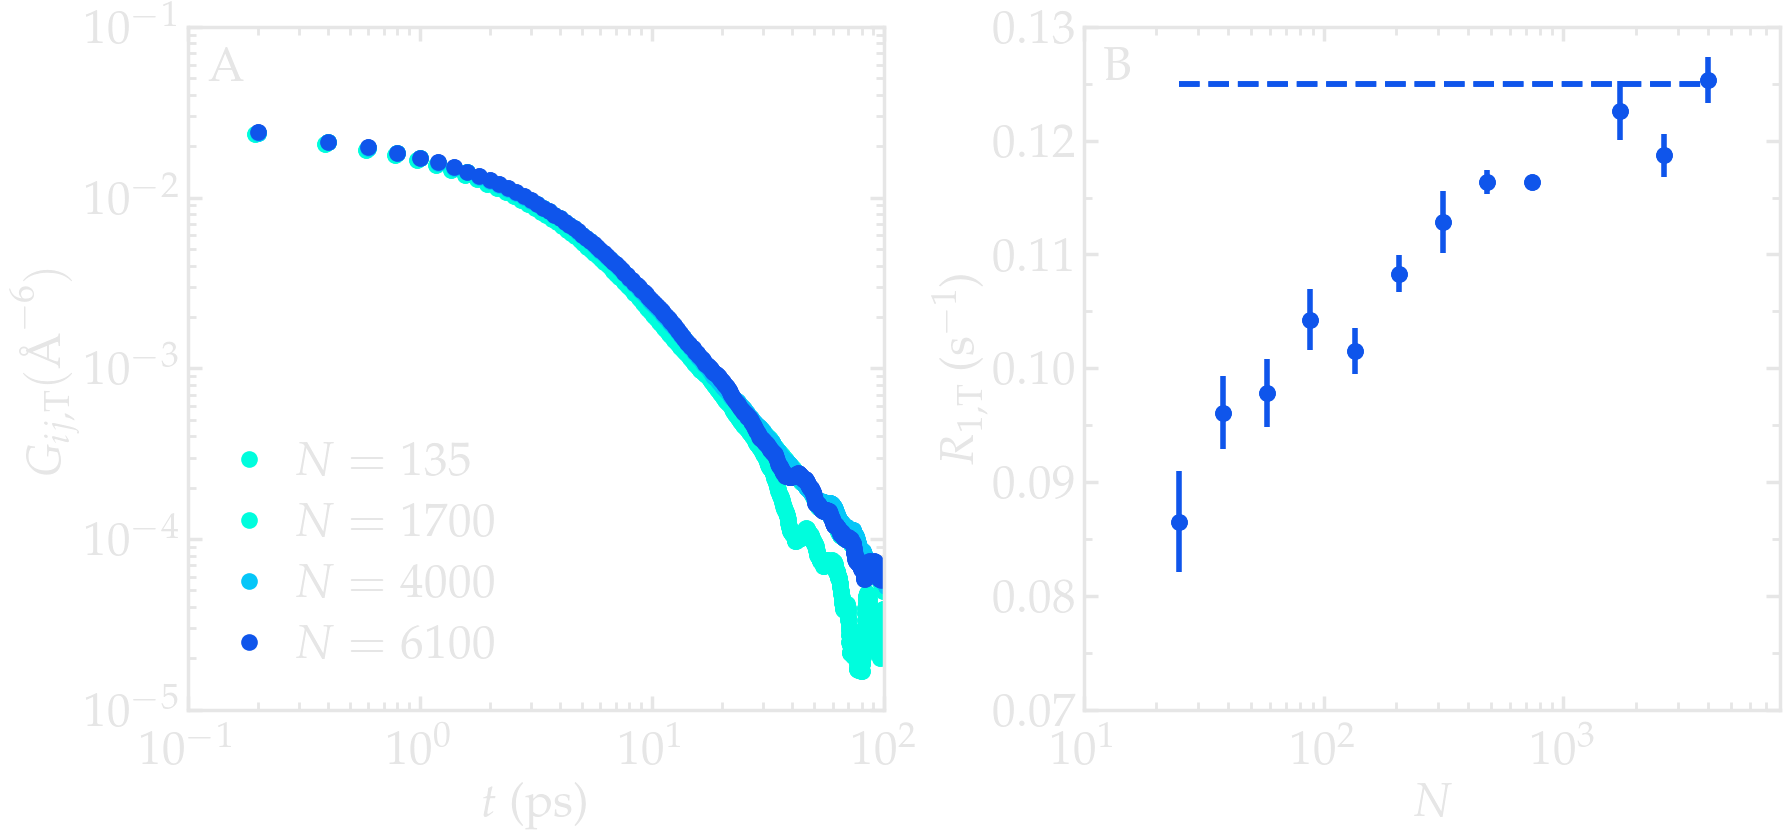

In [49]:
n = 500
type = "full"

for dark_mode in [False, True]:

    myplt = PltTools()
    myplt.prepare_figure(fig_size = (18, 8.5), dark_mode = dark_mode,
                         transparency = True, use_serif=True, n_colone = 2)

    # Panel 1
    colors = cmap_cyan_to_green_blue(np.linspace(0, 1, 4))

    myplt.add_panel()

    t, GT, GT_error = np.loadtxt("water-N/GT_N135_TIP4P.dat").T
    t, GR, GR_error = np.loadtxt("water-N/GR_N135_TIP4P.dat").T
    myplt.add_plot(x = t, y = GT,
                   # dy = np.sqrt(GT_error[::jump]+GR_error[::jump]),
                   type = "loglog", linewidth_data = 3,
                   marker = "o", data_color = colors[2][:3],
                   markersize = 12, data_label = r'$N = 135$')

    t, GT, GT_error = np.loadtxt("water-N/GT_N1717_TIP4P.dat").T
    t, GR, GR_error = np.loadtxt("water-N/GR_N1717_TIP4P.dat").T
    myplt.add_plot(x = t, y = GT,
                   # dy = np.sqrt(GT_error[::jump]+GR_error[::jump]),
                   type = "loglog", linewidth_data = 3,
                   marker = "o", data_color = colors[2][:3],
                   markersize = 12, data_label = r'$N = 1700$')

    t, GT, GT_error = np.loadtxt("water-N/GT_N4000_TIP4P.dat").T
    t, GR, GR_error = np.loadtxt("water-N/GR_N4000_TIP4P.dat").T
    myplt.add_plot(x = t, y = GT,
                   # dy = np.sqrt(GT_error[::jump]+GR_error[::jump]),
                   type = "loglog", linewidth_data = 3,
                   marker = "o", data_color = colors[1][:3],
                   markersize = 12, data_label = r'$N = 4000$')

    t, GT, GT_error = np.loadtxt("water-N/GT_N6106_TIP4P.dat").T
    t, GR, GR_error = np.loadtxt("water-N/GR_N6106_TIP4P.dat").T
    myplt.add_plot(x = t, y = GT,
                   # dy = np.sqrt(GT_error[::jump]+GR_error[::jump]),
                   type = "loglog", linewidth_data = 3,
                   marker = "o", data_color = colors[0][:3],
                   markersize = 12, data_label = r'$N = 6100$')
    
    myplt.complete_panel(xlabel = r'$t$ (ps)', ylabel = r'$G_{ij, \mathrm{T}} (\mathrm{\AA}^{-6})$',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(0.1, 100), y_boundaries=(1e-5, 0.1))

    myplt.add_panel()

    N, R1, R1_error, R1T, R1T_error, R1R, R1R_error, tauT, tauR, tauT_error, tauR_error = np.loadtxt("water-N/T1_TIP4P.dat")[:-1].T
    myplt.add_plot(x = N, y = R1T, dy = R1T_error, type = "semilogx", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3], markersize = 12)
    
    myplt.complete_panel(xlabel = r'$N$', ylabel = r'$R_{1, \mathrm{T}}$ (s$^{-1}$)',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(10, 8000), y_boundaries=(0.07, 0.13))

    myplt.add_plot(x = N, y = R1*0+0.125, type = "plot", linewidth_data = 3,
                marker = "--", data_color = colors[0][:3],
                markersize = 12) # , data_label = r'TIP4P')

    myplt.add_subplotlabels(type_label_panel = "A")
    myplt.save_figure(filename = "water-N", saving_path = git_path+path_figures)
    

  Pixels: width = 711.9 x height = 699.8
  Aspect ratio: 1.0174
  Pixels: width = 711.9 x height = 699.8
  Aspect ratio: 1.0174


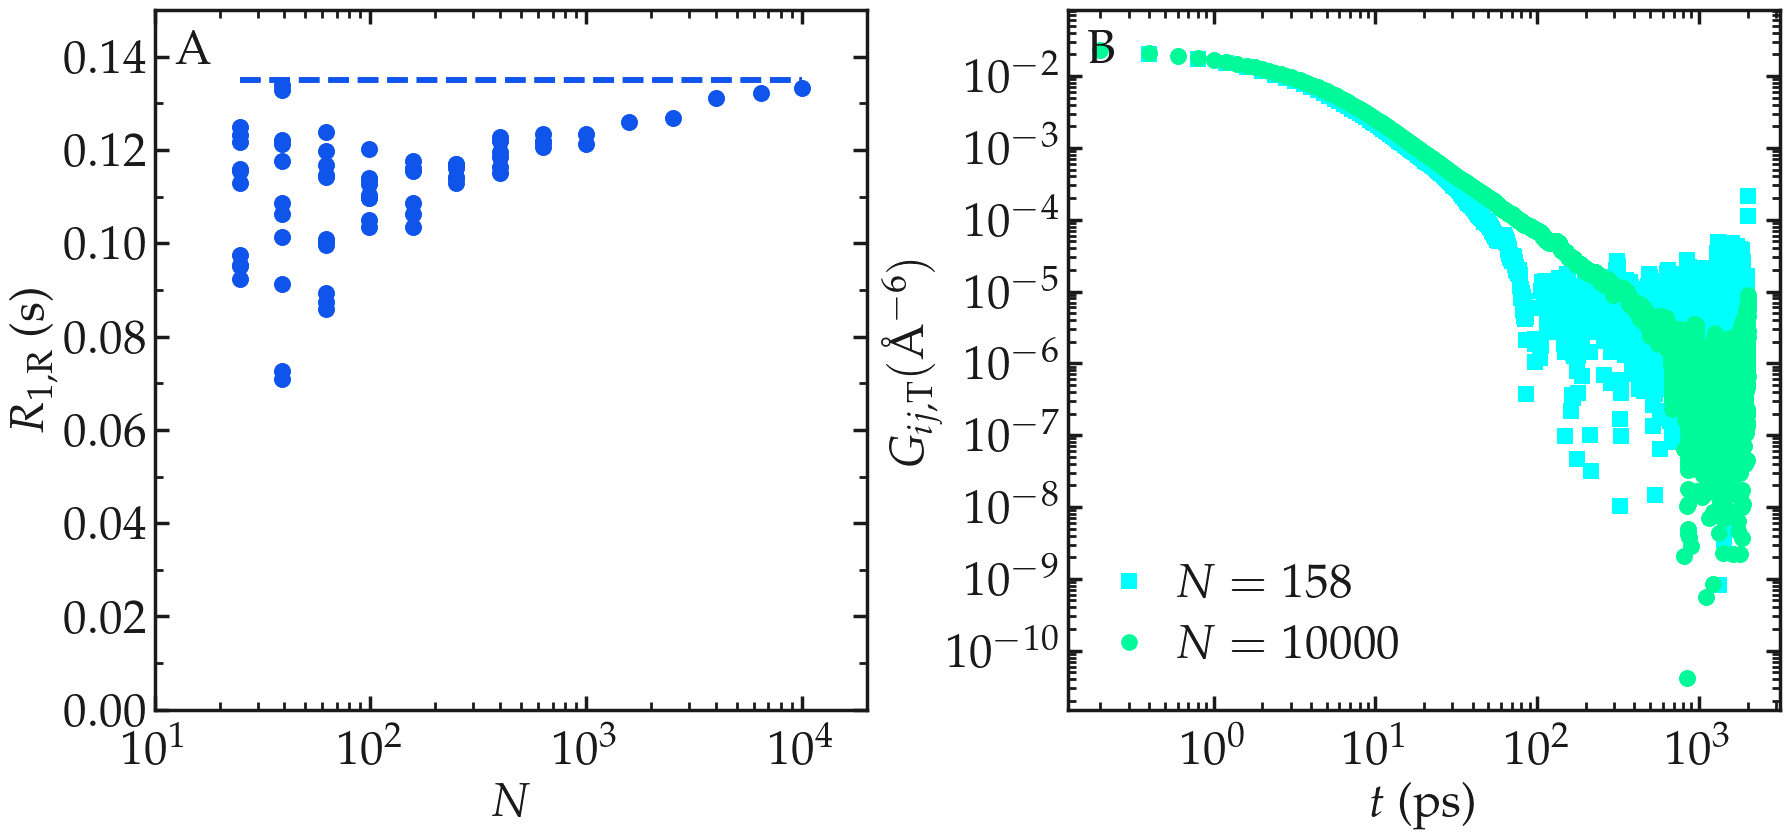

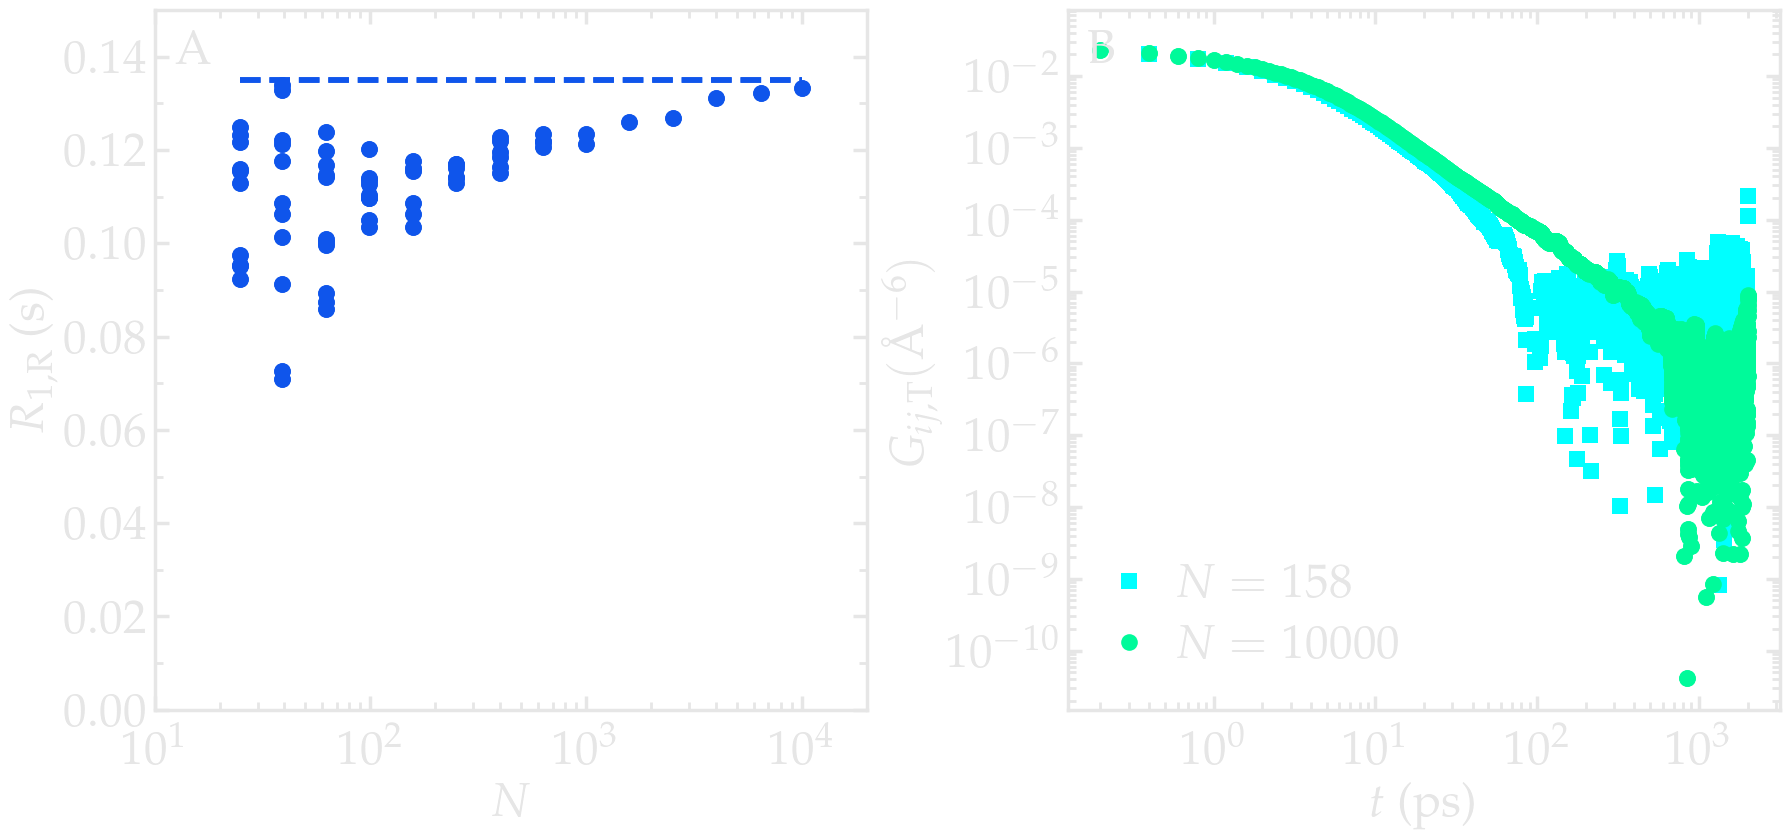